In [78]:
import sys
sys.path.append('../src')


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
from sklearn.metrics import silhouette_score, silhouette_samples, confusion_matrix
from datacleaning import customer_handle_missing_values

from utils import (
    scaling,
    plot_dendrogram,
    visualize_dimensionality_reduction
)


from clustering import(
    plot_silhouette
)

In [79]:
dataset = pd.read_csv('../data/clean_customer_info.csv', index_col= 0)

dataset.head()

,customer_name,customer_gender,customer_age,education_level,kids_home,teens_home,total_children,year_first_transaction,years_tenure,distinct_stores_visited,...,perc_spend_vegetables,perc_spend_meat_fish,perc_spend_petfood,perc_spend_tech_entertainment,perc_spend_groceries,perc_spend_alcohol,perc_spend_hygiene,latitude,longitude,is_customer_outlier
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Crystal Kitchens,female,56,Bsc,1,1,2,2020,6,3,...,0.020065,0.012964,0.020656,0.258687,0.631038,0.009521,0.029693,38.794428,-9.215739,0
4,Glenda Bauman,female,51,Bsc,1,0,1,2013,13,2,...,0.099442,0.002867,0.032867,0.064054,0.676815,0.004695,0.092918,38.751711,-9.179611,0
5,Antonio Campbell,male,55,Msc,0,0,0,2005,21,2,...,0.035694,0.098913,0.014277,0.006496,0.797929,0.007589,0.032607,38.780678,-9.160656,0
7,John Kelling,male,44,Unknown,0,0,0,2021,5,1,...,0.005618,0.137440,0.012306,0.184658,0.501137,0.075776,0.032437,38.739548,-9.148679,0
8,Arthur Dematteo,male,57,Unknown,0,0,0,2021,5,1,...,0.014730,0.080746,0.017095,0.469008,0.356127,0.027833,0.011513,38.733071,-9.188188,0


In [80]:
dataset.columns

Index(['customer_name', 'customer_gender', 'customer_age', 'education_level',
       'kids_home', 'teens_home', 'total_children', 'year_first_transaction',
       'years_tenure', 'distinct_stores_visited', 'number_complaints',
       'typical_hour', 'time_of_day', 'lifetime_total_distinct_products',
       'percentage_of_products_bought_promotion', 'lifetime_spend_groceries',
       'lifetime_spend_vegetables', 'lifetime_spend_meat',
       'lifetime_spend_fish', 'lifetime_spend_meat_fish',
       'lifetime_spend_electronics_videogames', 'lifetime_spend_electronics',
       'lifetime_spend_videogames', 'lifetime_spend_nonalcohol_drinks',
       'lifetime_spend_alcohol_drinks', 'lifetime_spend_hygiene',
       'lifetime_spend_petfood', 'total_spend', 'perc_spend_vegetables',
       'perc_spend_meat_fish', 'perc_spend_petfood',
       'perc_spend_tech_entertainment', 'perc_spend_groceries',
       'perc_spend_alcohol', 'perc_spend_hygiene', 'latitude', 'longitude',
       'is_customer_ou

In [81]:
features = [
    'customer_age',
    'number_complaints',
    'total_children',
    'years_tenure',
    'distinct_stores_visited',


    'percentage_of_products_bought_promotion',
    'perc_spend_vegetables',
    'perc_spend_meat_fish',
    'perc_spend_tech_entertainment',
    'perc_spend_hygiene',
]

X = dataset[features].copy()
X.columns

Index(['customer_age', 'number_complaints', 'total_children', 'years_tenure',
       'distinct_stores_visited', 'percentage_of_products_bought_promotion',
       'perc_spend_vegetables', 'perc_spend_meat_fish',
       'perc_spend_tech_entertainment', 'perc_spend_hygiene'],
      dtype='str')

In [82]:
# Depois faz o scaling normalmente
X_scaled = scaling(X)

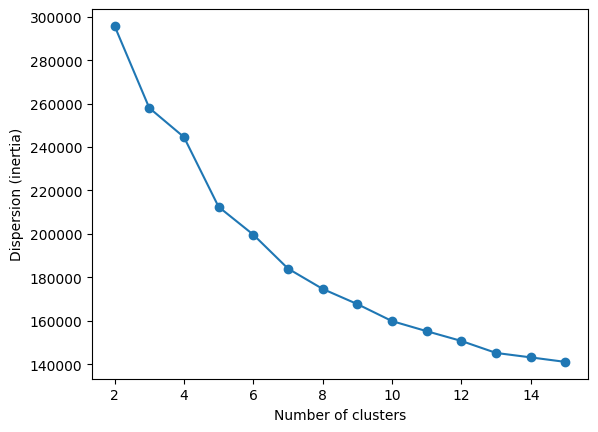

In [83]:
K_range = 15

inertias = []

for k in range(2, K_range+1):
    experimental_kmeans = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    inertias.append(experimental_kmeans.inertia_)

plt.plot(range(2, K_range+1), inertias, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Dispersion (inertia)')
plt.show()

In [ ]:
scores = []

for k in range(2,K_range+1):
    experimental_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = experimental_kmeans.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))
        
plt.figure(figsize=(8, 5))
plt.plot(range(2,K_range+1), scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')
plt.show()

k=6 | silhouette=0.1630
k=7 | silhouette=0.1672
k=8 | silhouette=0.1662
k=9 | silhouette=0.1708
k=10 | silhouette=0.1639


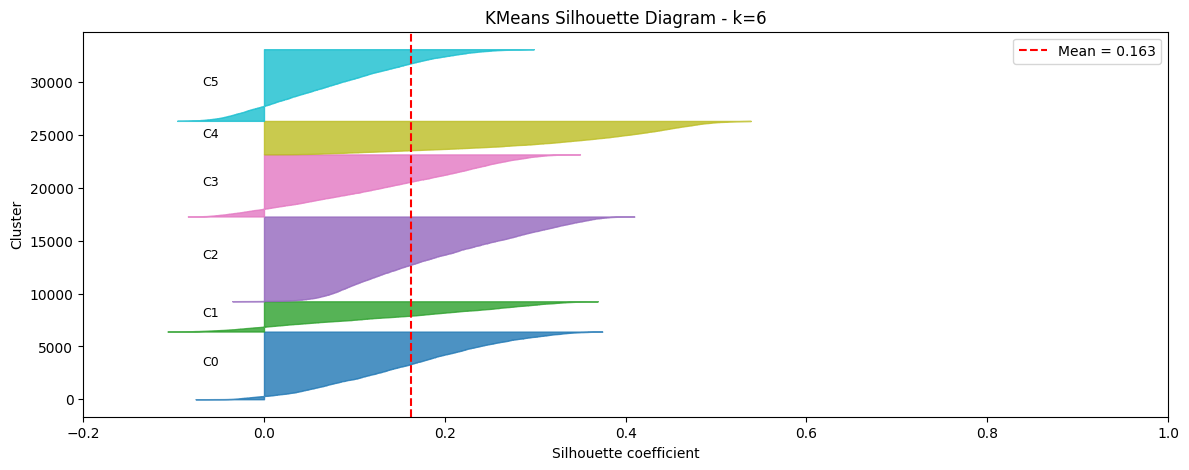

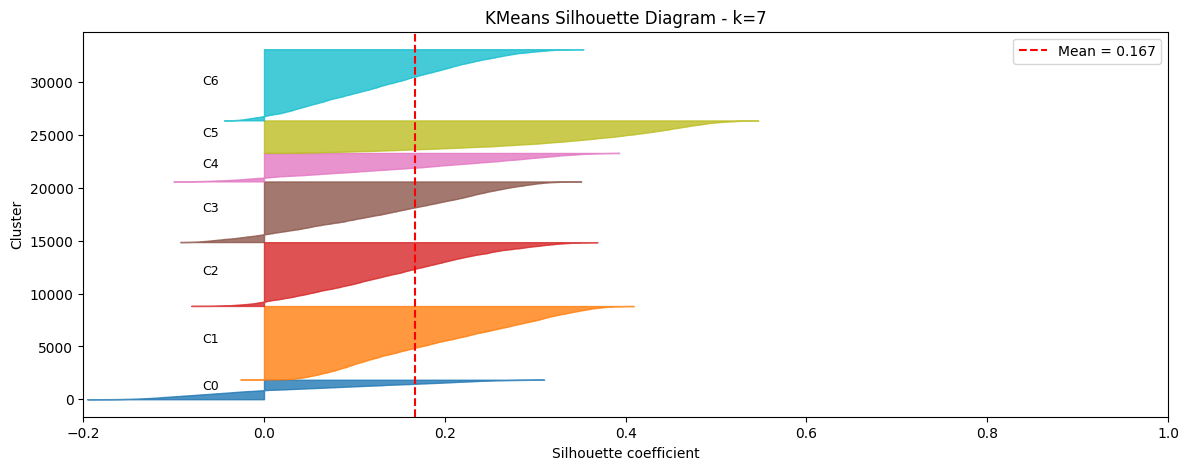

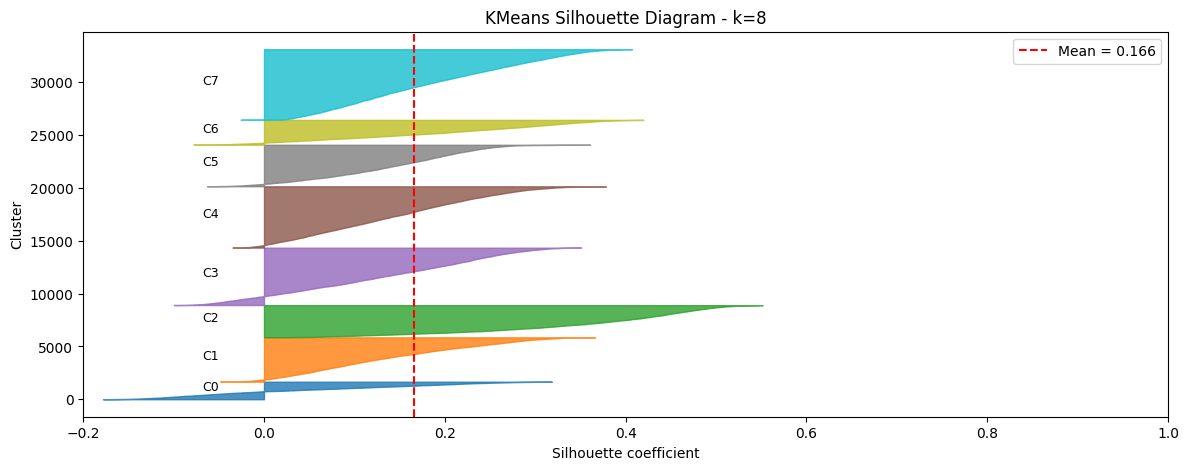

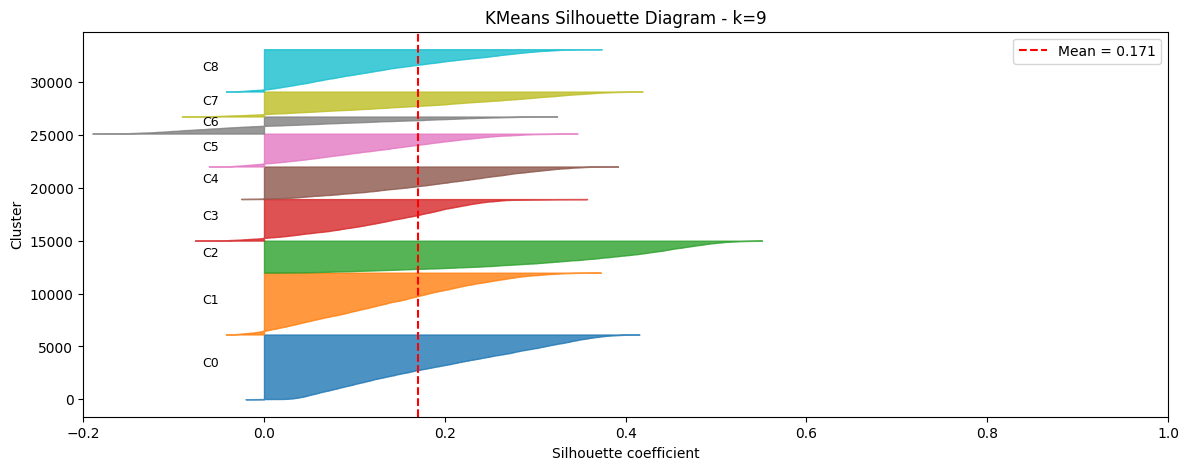

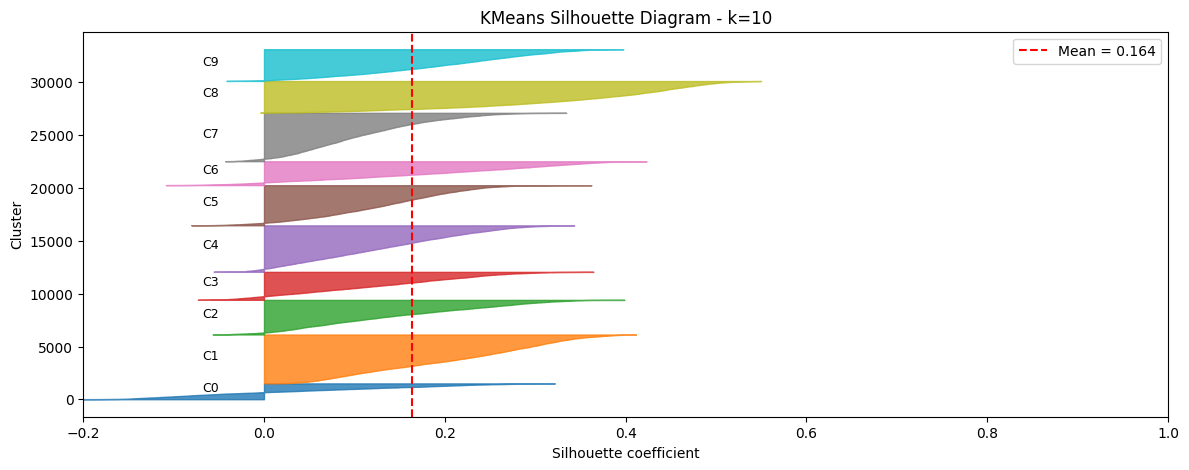

In [ ]:
for k in [6, 7, 8, 9, 10]:
    experimental_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = experimental_kmeans.fit_predict(X_scaled)

    score = plot_silhouette(
        X_scaled,
        labels,
        title=f"KMeans Silhouette Diagram - k={k}"
    )

    print(f"k={k} | silhouette={score:.4f}")

In [ ]:
kmeans = KMeans(n_clusters= 8, random_state=0, n_init=10).fit(X_scaled)
dataset['cluster_kmeans'] = kmeans.predict(X_scaled)


In [ ]:
dataset["cluster_kmeans"].value_counts()

cluster_kmeans
0    6612
5    5844
2    5416
3    4178
7    3936
4    3029
1    2350
6    1673
Name: count, dtype: int64

In [ ]:
X['cluster_kmeans'] = dataset['cluster_kmeans']

In [ ]:
X.groupby("cluster_kmeans").mean().T

cluster_kmeans,0,1,2,3,4,5,6,7
customer_age,63.722928,58.468511,58.190362,36.082097,57.279960,61.873546,59.036461,41.134654
number_complaints,0.574410,0.891915,0.651588,0.516276,1.063387,0.844798,0.937238,2.403709
total_children,1.732910,6.941702,1.927068,1.381283,0.555959,1.418891,1.573819,2.539126
years_tenure,14.502420,13.558723,10.421344,6.483006,8.898646,11.634155,11.466826,9.167683
distinct_stores_visited,2.514368,3.294894,3.538589,3.314983,1.443051,4.683778,3.671847,2.373476
percentage_of_products_bought_promotion,0.165131,0.203800,0.133337,0.295819,0.260300,0.656956,0.435972,0.446613
perc_spend_vegetables,0.030227,0.022957,0.127568,0.026144,0.007854,0.023162,0.055407,0.019301
perc_spend_meat_fish,0.054599,0.078748,0.015173,0.055617,0.076116,0.064068,0.190502,0.067840
perc_spend_tech_entertainment,0.077446,0.152887,0.110845,0.089119,0.495124,0.074147,0.159820,0.084232
perc_spend_hygiene,0.033418,0.026013,0.096795,0.031743,0.011033,0.030481,0.084930,0.029970


In [ ]:
numeric_cols = dataset.select_dtypes(include='number')

numeric_cols = numeric_cols.drop(
    ['kids_home', 
    'teens_home', 
    'year_first_transaction', 
    'lifetime_spend_meat',  
    'lifetime_spend_fish',
    'lifetime_spend_nonalcohol_drinks',
    'latitude',
    'longitude'], axis = 1)

numeric_cols.groupby("cluster_kmeans").mean().T

cluster_kmeans,0,1,2,3,4,5,6,7
customer_age,63.722928,58.468511,58.190362,36.082097,57.279960,61.873546,59.036461,41.134654
total_children,1.732910,6.941702,1.927068,1.381283,0.555959,1.418891,1.573819,2.539126
years_tenure,14.502420,13.558723,10.421344,6.483006,8.898646,11.634155,11.466826,9.167683
distinct_stores_visited,2.514368,3.294894,3.538589,3.314983,1.443051,4.683778,3.671847,2.373476
number_complaints,0.574410,0.891915,0.651588,0.516276,1.063387,0.844798,0.937238,2.403709
typical_hour,10.855717,10.159149,12.325702,13.659646,17.398811,13.921287,13.067543,10.947917
lifetime_total_distinct_products,175.063218,297.480000,104.179284,147.353997,109.903929,156.364819,150.343694,97.852134
percentage_of_products_bought_promotion,0.165131,0.203800,0.133337,0.295819,0.260300,0.656956,0.435972,0.446613
lifetime_spend_groceries,22207.756957,24944.249787,9602.984306,18786.163715,8177.128425,19633.703457,3748.102809,14479.588923
lifetime_spend_vegetables,714.682547,801.558298,1750.176514,559.593346,178.073622,421.771218,447.392708,347.190295


In [ ]:
cluster_names = {
    0: "Older Long-Tenure",
    1: "Clean and Green",
    2: "Young Most Recent Customers",
    3: "Tech Enthusiasts",
    4: "Promotion Seekers",
    5: "Large Families",
    6: "Protein Lovers",
    7: "Service Sensitive"
}


dataset['cluster_name'] = dataset['cluster_kmeans'].map(cluster_names)

In [ ]:
dataset.head()

,customer_name,customer_gender,customer_age,education_level,kids_home,teens_home,total_children,year_first_transaction,years_tenure,distinct_stores_visited,...,perc_spend_petfood,perc_spend_tech_entertainment,perc_spend_groceries,perc_spend_alcohol,perc_spend_hygiene,latitude,longitude,is_customer_outlier,cluster_kmeans,cluster_name
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Crystal Kitchens,female,56,Bsc,1,1,2,2020,6,3,...,0.020656,0.258687,0.631038,0.009521,0.029693,38.794428,-9.215739,0,3,Tech Enthusiasts
4,Glenda Bauman,female,51,Bsc,1,0,1,2013,13,2,...,0.032867,0.064054,0.676815,0.004695,0.092918,38.751711,-9.179611,0,2,Young Most Recent Customers
5,Antonio Campbell,male,55,Msc,0,0,0,2005,21,2,...,0.014277,0.006496,0.797929,0.007589,0.032607,38.780678,-9.160656,0,0,Older Long-Tenure
7,John Kelling,male,44,Unknown,0,0,0,2021,5,1,...,0.012306,0.184658,0.501137,0.075776,0.032437,38.739548,-9.148679,0,7,Service Sensitive
8,Arthur Dematteo,male,57,Unknown,0,0,0,2021,5,1,...,0.017095,0.469008,0.356127,0.027833,0.011513,38.733071,-9.188188,0,4,Promotion Seekers


In [ ]:
experimental_hierarchical = AgglomerativeClustering(linkage='ward', distance_threshold=0, n_clusters=None).fit(X_scaled)

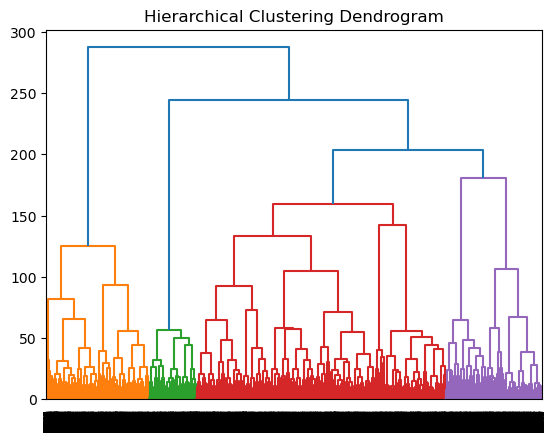

In [ ]:
fig, ax = plt.subplots()
plt.title("Hierarchical Clustering Dendrogram")
# plot the top three levels of the dendrogram
plot_dendrogram(experimental_hierarchical, truncate_mode="level", p=50)
plt.show()


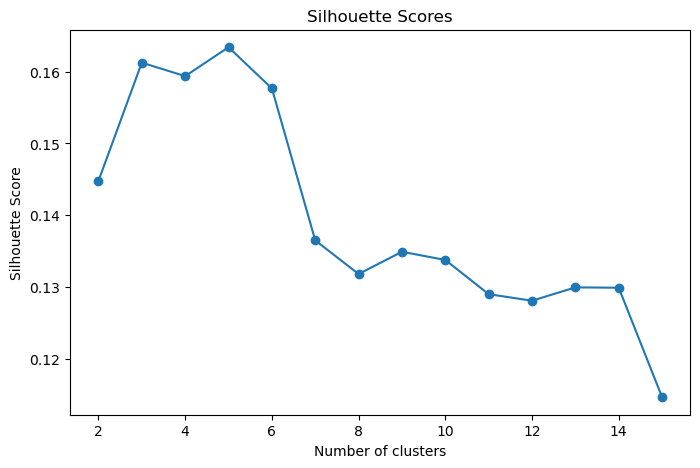

In [ ]:
scores = []

for k in range(2,K_range+1):
    experimental_hierarchical = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = experimental_hierarchical.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))
        
plt.figure(figsize=(8, 5))
plt.plot(range(2,K_range+1), scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')
plt.show()

In [ ]:
dataset['cluster_agglomerative'] = AgglomerativeClustering(linkage='ward', n_clusters=8).fit_predict(X_scaled)

In [ ]:
dataset.columns

Index(['customer_name', 'customer_gender', 'customer_age', 'education_level',
       'kids_home', 'teens_home', 'total_children', 'year_first_transaction',
       'years_tenure', 'distinct_stores_visited', 'number_complaints',
       'typical_hour', 'time_of_day', 'lifetime_total_distinct_products',
       'percentage_of_products_bought_promotion', 'lifetime_spend_groceries',
       'lifetime_spend_vegetables', 'lifetime_spend_meat',
       'lifetime_spend_fish', 'lifetime_spend_meat_fish',
       'lifetime_spend_electronics_videogames', 'lifetime_spend_electronics',
       'lifetime_spend_videogames', 'lifetime_spend_nonalcohol_drinks',
       'lifetime_spend_alcohol_drinks', 'lifetime_spend_hygiene',
       'lifetime_spend_petfood', 'total_spend', 'perc_spend_vegetables',
       'perc_spend_meat_fish', 'perc_spend_petfood',
       'perc_spend_tech_entertainment', 'perc_spend_groceries',
       'perc_spend_alcohol', 'perc_spend_hygiene', 'latitude', 'longitude',
       'is_customer_ou

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33038 entries, 3 to 40000
Data columns (total 41 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_name                            33038 non-null  object 
 1   customer_gender                          33038 non-null  object 
 2   customer_age                             33038 non-null  int64  
 3   education_level                          33038 non-null  object 
 4   kids_home                                33038 non-null  int64  
 5   teens_home                               33038 non-null  int64  
 6   total_children                           33038 non-null  int64  
 7   year_first_transaction                   33038 non-null  int64  
 8   years_tenure                             33038 non-null  int64  
 9   distinct_stores_visited                  33038 non-null  int64  
 10  number_complaints                        33038 non-

In [ ]:
pd.DataFrame(
    confusion_matrix(
        dataset['cluster_kmeans'],
        dataset['cluster_agglomerative']
    ),
    index=[f'K-Means {i} Cluster' for i in np.arange(0, 8)],
    columns=[f'Hierarchical {i} Cluster' for i in np.arange(0, 8)]
)

,Hierarchical 0 Cluster,Hierarchical 1 Cluster,Hierarchical 2 Cluster,Hierarchical 3 Cluster,Hierarchical 4 Cluster,Hierarchical 5 Cluster,Hierarchical 6 Cluster,Hierarchical 7 Cluster
K-Means 0 Cluster,1028,73,55,1645,250,3216,0,317
K-Means 1 Cluster,5316,55,0,23,0,8,6,19
K-Means 2 Cluster,465,28,73,340,179,510,0,2550
K-Means 3 Cluster,1,1,2926,33,5,26,0,34
K-Means 4 Cluster,26,23,3,4065,48,56,2,1672
K-Means 5 Cluster,1,95,1,76,2138,24,0,13
K-Means 6 Cluster,5,46,37,564,3,226,592,197
K-Means 7 Cluster,51,3361,37,212,91,54,1,136


In [ ]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(
    dataset['cluster_kmeans'],
    dataset['cluster_agglomerative']
)

print("Adjusted Rand Index:", round(ari, 3))

Adjusted Rand Index: 0.504


In [ ]:
tsne = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate="auto",
    init="pca",
    random_state=0
)

tsne_transformation = tsne.fit_transform(X_scaled)


c:\Users\tiago\OneDrive - NOVAIMS\2ºano 2º semestre\Machine Learning II\ml_project\notebooks\../src\utils.py:85: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles = [plt.scatter([], [], c=rgba, label=label) for rgba, label in zip(rgba_values, labels)]


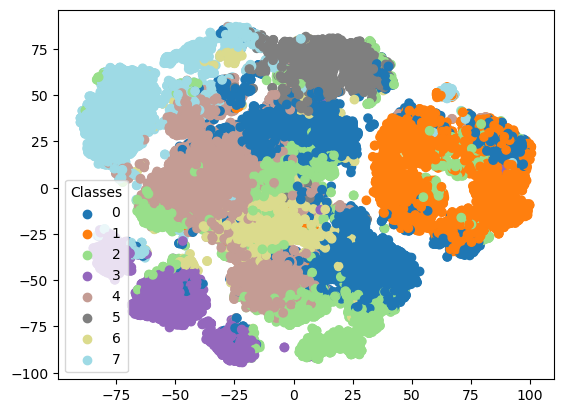

In [ ]:
visualize_dimensionality_reduction(tsne_transformation, dataset['cluster_kmeans'])    


In [ ]:
umap = UMAP(n_neighbors=50, random_state=0)



umap_transformation = umap.fit_transform(X_scaled)

c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


c:\Users\tiago\OneDrive - NOVAIMS\2ºano 2º semestre\Machine Learning II\ml_project\notebooks\../src\utils.py:85: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles = [plt.scatter([], [], c=rgba, label=label) for rgba, label in zip(rgba_values, labels)]


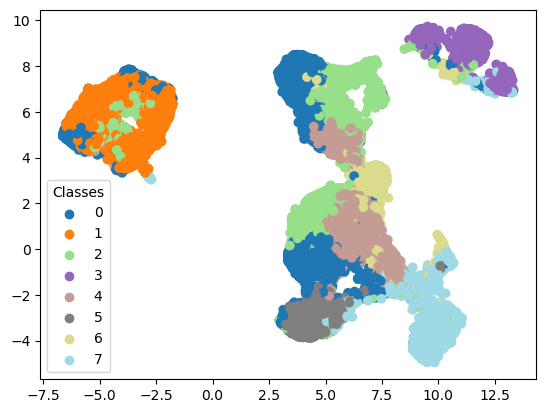

In [ ]:
visualize_dimensionality_reduction(umap_transformation, dataset['cluster_kmeans'])

## Export final customer clusters

The final K-Means segmentation is exported so it can be used in the association rules notebook and in the final project deliverables.

In [ ]:
dataset_export = dataset.reset_index()

In [ ]:
dataset_export[['customer_id', 'cluster_kmeans', 'cluster_name']].head()

,customer_id,cluster_kmeans,cluster_name
0,3,2,Young Grocery
1,4,1,Vegetables-Hygiene Oriented
2,5,0,Older Long-Tenure Grocery
3,7,7,Service Sensitive
4,8,3,Tech Enthusiasts


In [ ]:
customer_clusters = dataset_export[['customer_id', 'cluster_kmeans', 'cluster_name']].copy()

customer_clusters.to_csv("../data/customer_clusters.csv", index=False)

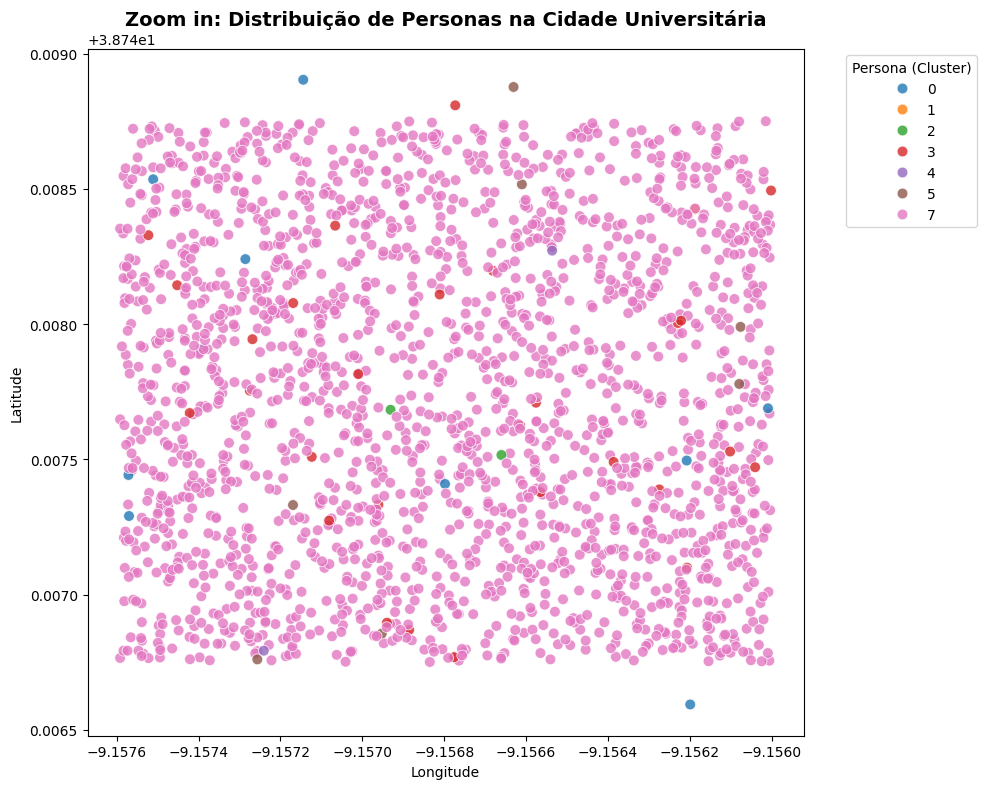

--- QUEM MORA NESTE QUADRADO SINTÉTICO? ---
Cluster 7: 1968 clientes (97.5%)
Cluster 3: 28 clientes (1.4%)
Cluster 0: 10 clientes (0.5%)
Cluster 5: 7 clientes (0.3%)
Cluster 4: 2 clientes (0.1%)
Cluster 2: 2 clientes (0.1%)
Cluster 1: 1 clientes (0.0%)


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# PASSO 1: LIMITES DO QUADRADO (Ajusta os valores olhando para os eixos do teu mapa)
# ---------------------------------------------------------
lat_min = 38.7465  # Ponto mais baixo do quadrado (Latitude)
lat_max = 38.749  # Ponto mais alto do quadrado (Latitude)
lon_min = -9.1576  # Ponto mais à esquerda (Longitude)
lon_max = -9.156  # Ponto mais à direita (Longitude)

# ---------------------------------------------------------
# PASSO 2: CORTAR O DATASET (Ficar apenas com quem vive no quadrado)
# ---------------------------------------------------------
mini_cluster_data = dataset[
    (dataset['latitude'] >= lat_min) & (dataset['latitude'] <= lat_max) &
    (dataset['longitude'] >= lon_min) & (dataset['longitude'] <= lon_max)
].copy()

# ---------------------------------------------------------
# PASSO 3: DESENHAR O MAPA COM ZOOM E CORES
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=mini_cluster_data,
    x='longitude',
    y='latitude',
    hue='cluster_kmeans', # Vai usar os teus 8 grupos finais
    palette='tab10',      # Paleta de cores bem contrastante
    s=60,                 # Pontos maiores porque fizemos zoom
    alpha=0.8
)

plt.title('Zoom in: Distribuição de Personas na Cidade Universitária', fontsize=14, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Persona (Cluster)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# PASSO 4: A VERDADE MATEMÁTICA (Imprime as percentagens na consola)
# ---------------------------------------------------------
print("--- QUEM MORA NESTE QUADRADO SINTÉTICO? ---")
if len(mini_cluster_data) == 0:
    print("Aviso: O quadrado está vazio. Afina os valores de lat_min/max e lon_min/max no Passo 1!")
else:
    contagem = mini_cluster_data['cluster_kmeans'].value_counts()
    percentagens = mini_cluster_data['cluster_kmeans'].value_counts(normalize=True) * 100
    
    for cluster, qtd in contagem.items():
        print(f"Cluster {cluster}: {qtd} clientes ({percentagens[cluster]:.1f}%)")

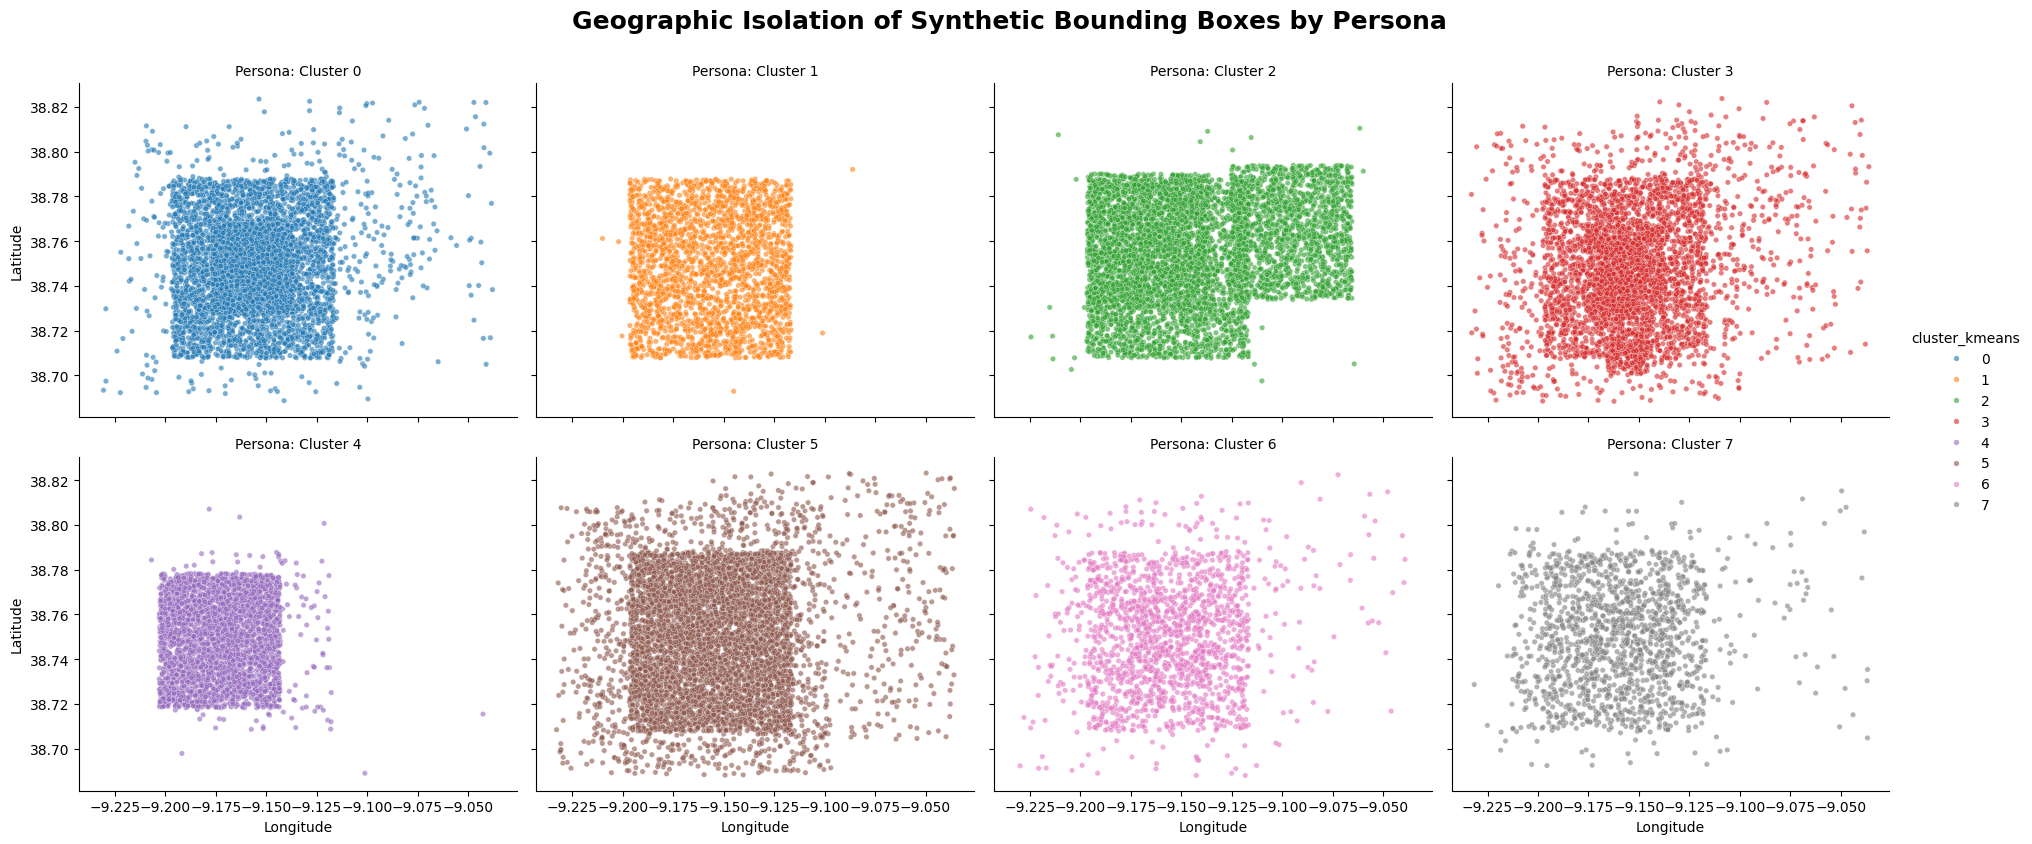

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Using relplot to create a grid: one map per cluster
g = sns.relplot(
    data=dataset,
    x='longitude',
    y='latitude',
    col='cluster_kmeans', # This splits the data into separate plots!
    col_wrap=4,           # Defines 4 maps per row
    hue='cluster_kmeans',
    palette='tab10',
    s=15,                 # Dot size
    alpha=0.6,            # Transparency
    height=4,             # Height of each individual map
    aspect=1.2            # Width ratio
)

# Formatting for the university report
g.fig.suptitle('Geographic Isolation of Synthetic Bounding Boxes by Persona', y=1.05, fontsize=18, fontweight='bold')
g.set_axis_labels('Longitude', 'Latitude')
g.set_titles('Persona: Cluster {col_name}') # Names each subplot automatically

plt.show()